<a href="https://colab.research.google.com/github/Qalani/Dissertation/blob/main/Rules_vs_Logistic_Regression_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rules-based vs Logistic Regression classifier comparison

This standalone notebook compares the **local rules-based classifier** with the **local Logistic Regression classifier** produced by `Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb`.

It **does not retrain or alter either classifier**. It works from the classified GeoTIFFs already written to the classifier batch-output directory.

## Outputs

The analysis is performed **separately for Sentinel-2 and Sentinel-1** and exports:

- a paired-scene provenance manifest;
- per-scene overall agreement and Cohen's $\kappa$;
- pooled and per-scene Logistic Regression × rules agreement matrices;
- class-specific intersection-over-union (IoU) and Dice concordance;
- mapped class areas for each classifier on the **same common-valid pixels**;
- signed and absolute class-area differences;
- scene-level and monthly floating-plant area comparisons;
- georeferenced disagreement-transition GeoTIFFs for QGIS;
- dissertation-ready PNG figures and CSV tables.

> **Important:** neither classifier is treated as ground truth. Agreement, $\kappa$, IoU and Dice measure **concordance between methods**, not classification accuracy. Accuracy should be reported separately from validation against labelled reference data.

## 1. Mount Google Drive

In [8]:
from pathlib import Path

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
else:
    print("Not running in Colab; skipping Google Drive mount.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Imports

In [9]:
# Uncomment in a fresh environment if required:
# !pip -q install rasterio pandas numpy matplotlib pyproj

import hashlib
import math
import re
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import Window
from pyproj import CRS, Geod

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

## 3. Configuration

The defaults match the current Winam classifier output structure and intentionally reject legacy export schemas.

Class coding is **sensor-dependent** and is copied from `S2_CLASS_NAMES` / `S1_CLASS_NAMES` in `Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb`. Sentinel-2 carries a fourth class (surface algae, code `3`); Sentinel-1 cannot separate surface algae from open water in SAR backscatter, so its mapping folds them into a single class and never writes code `3`. Both sensors code floating plants as `2` and NoData as `255`.

In [10]:
# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
DRIVE_MYDRIVE = Path("/content/drive/MyDrive")

CLASSIFIER_ROOT = DRIVE_MYDRIVE / "Winam_RF_Training_Data"
CLASSIFIER_BATCH_DIR = CLASSIFIER_ROOT / "outputs" / "full_stack_batch"
CLASSIFIED_DIR = CLASSIFIER_BATCH_DIR / "classified_geotiffs"

OUTPUT_DIR = CLASSIFIER_ROOT / "outputs" / "rules_vs_logistic_regression"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
DISAGREEMENT_DIR = OUTPUT_DIR / "disagreement_geotiffs"

USE_LOCAL_STAGING = True
LOCAL_STAGE_DIR = Path("/content/rules_vs_lr_stage")

# ---------------------------------------------------------------------
# Scene / provenance filtering
# ---------------------------------------------------------------------
SENSOR_FILTER = ["S2", "S1"]

# Require current predictor schema tokens in filename prefixes.
REQUIRED_SCHEMA_TOKEN = {
    "S2": "s2_whlev_temporal_v1",
    "S1": "s1_scc_temporal_v1",
}

# Model output must be Logistic Regression.
MODEL_SLUG_REGEX = re.compile(r"logistic", re.IGNORECASE)

MODEL_SLUG_PREFERENCE = (
    "logistic_regression_baseline",
    "logistic_regression",
    "logistic",
)

START_DATE = None       # e.g. "2021-01-01"
END_DATE = None         # e.g. "2023-12-31"
MAX_SCENES_PER_SENSOR = None

# ---------------------------------------------------------------------
# Raster class coding
# ---------------------------------------------------------------------
NODATA_VALUE = 255

# Class coding is sensor-dependent. These maps are the S2_CLASS_NAMES and
# S1_CLASS_NAMES defined in Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb,
# and they apply to the Logistic Regression and rules-based rasters alike:
#
#   S2 keeps surface algae as its own class (code 3). Both the S2 training
#      labels ('A' -> 3) and the S2 rule branch NDMI >= 0.63 emit it, so an S2
#      raster legitimately contains four class codes.
#   S1 cannot separate surface algae from open water in SAR backscatter, so the
#      S1 training mapping folds 'A' into code 0 and no S1 raster contains a 3.
#
# Both sensors code floating plants as 2, so FLOATING_CLASS_CODE stays global.
SENSOR_CLASS_LABELS = {
    "S2": {
        0: "Open water",
        1: "LEV",
        2: "Floating plants",
        3: "Surface algae",
    },
    "S1": {
        0: "Open water / surface algae",
        1: "LEV",
        2: "Floating plants",
    },
}

FLOATING_CLASS_CODE = 2


def class_labels_for(sensor):
    """Return the {class code: label} map for one sensor."""
    try:
        return SENSOR_CLASS_LABELS[sensor]
    except KeyError:
        raise KeyError(
            f"No class coding is configured for sensor {sensor!r}. "
            f"Configured sensors: {sorted(SENSOR_CLASS_LABELS)}."
        ) from None


def class_codes_for(sensor):
    """Return the sorted tuple of valid class codes for one sensor."""
    return tuple(sorted(class_labels_for(sensor)))


# Fail during configuration rather than part-way through a long batch.
for _sensor in SENSOR_FILTER:
    _labels = class_labels_for(_sensor)

    if FLOATING_CLASS_CODE not in _labels:
        raise ValueError(
            f"{_sensor} class coding has no floating-plant code "
            f"{FLOATING_CLASS_CODE}: {_labels}."
        )

    if NODATA_VALUE in _labels:
        raise ValueError(
            f"{_sensor} class coding reuses NoData={NODATA_VALUE} as a class code."
        )

    # Disagreement transitions are written as 10*(LR+1)+(rules+1) into a uint8
    # band, so the largest class code has to stay inside that budget.
    _max_code = max(_labels)
    _max_transition = 10 * (_max_code + 1) + (_max_code + 1)
    if _max_transition >= NODATA_VALUE:
        raise ValueError(
            f"{_sensor} class code {_max_code} encodes disagreement transition "
            f"{_max_transition}, which collides with NoData={NODATA_VALUE}. "
            "Widen the transition encoding before adding further classes."
        )

# If a raster contains any non-NoData code outside its sensor's class codes the
# notebook stops immediately rather than silently dropping or relabelling it.
FAIL_ON_UNKNOWN_CLASS_CODE = True

# ---------------------------------------------------------------------
# Comparison behaviour
# ---------------------------------------------------------------------
STRICT_GRID_MATCH = True
READ_BLOCKSIZE = 2048

WRITE_DISAGREEMENT_RASTERS = True
OVERWRITE_OUTPUTS = False

N_TOP_DISAGREEMENT_QUICKLOOKS = 4

for p in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, DISAGREEMENT_DIR, LOCAL_STAGE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Classified raster directory:", CLASSIFIED_DIR)
print("Output directory:", OUTPUT_DIR)
for _sensor in SENSOR_FILTER:
    print(f"{_sensor} class mapping:", class_labels_for(_sensor))

Classified raster directory: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs
Output directory: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression
S2 class mapping: {0: 'Open water', 1: 'LEV', 2: 'Floating plants', 3: 'Surface algae'}
S1 class mapping: {0: 'Open water / surface algae', 1: 'LEV', 2: 'Floating plants'}


## 4. Discover and pair classifier outputs

The parser accepts the current schema-token filename forms as well as older forms, but `REQUIRED_SCHEMA_TOKEN` determines what is retained.

Sentinel-1 `_patch_cleaned.tif` model outputs are preferred over their raw equivalents. Google Drive collision copies such as `file (1).tif` are deprioritised.

In [11]:
_DATE_AT_END_RE = re.compile(
    r"(?P<start>\d{4}-\d{2}-\d{2})_to_(?P<end>\d{4}-\d{2}-\d{2})$"
)
_DRIVE_COLLISION_RE = re.compile(r"\s\((\d+)\)$")


def parse_scene_prefix(prefix):
    prefix = str(prefix)
    lower = prefix.lower()

    if lower.startswith("winam_s2"):
        sensor = "S2"
    elif lower.startswith("winam_s1"):
        sensor = "S1"
    else:
        return None

    m = _DATE_AT_END_RE.search(prefix)
    if not m:
        return None

    return {
        "prefix": prefix,
        "sensor": sensor,
        "start_date": m.group("start"),
        "end_date": m.group("end"),
    }


def strip_drive_collision(stem):
    return _DRIVE_COLLISION_RE.sub("", str(stem))


def parse_classifier_file(path):
    path = Path(path)
    if path.suffix.lower() not in {".tif", ".tiff"}:
        return None

    raw_stem = path.stem
    stem = strip_drive_collision(raw_stem)
    marker = "_local_"
    if marker not in stem:
        return None

    prefix, rest = stem.split(marker, 1)
    parsed = parse_scene_prefix(prefix)
    if parsed is None:
        return None

    if rest == "rules":
        role, model_slug, cleaned = "rule", "", False
    elif rest.endswith("_proba"):
        role, model_slug, cleaned = "proba", rest[:-len("_proba")], False
    elif rest.endswith("_patch_cleaned"):
        role, model_slug, cleaned = "model", rest[:-len("_patch_cleaned")], True
    else:
        role, model_slug, cleaned = "model", rest, False

    return {
        **parsed,
        "path": str(path),
        "role": role,
        "model_slug": model_slug,
        "patch_cleaned": bool(cleaned),
        "drive_collision_copy": bool(_DRIVE_COLLISION_RE.search(raw_stem)),
    }


def model_preference_score(rec):
    slug = str(rec["model_slug"]).lower()
    try:
        slug_rank = next(
            i for i, token in enumerate(MODEL_SLUG_PREFERENCE)
            if token.lower() in slug
        )
    except StopIteration:
        slug_rank = len(MODEL_SLUG_PREFERENCE)

    return (
        0 if rec["patch_cleaned"] else 1,
        slug_rank,
        1 if rec["drive_collision_copy"] else 0,
        rec["path"],
    )


def ordinary_file_score(rec):
    return (
        1 if rec["drive_collision_copy"] else 0,
        rec["path"],
    )


def discover_pairs(classified_dir):
    classified_dir = Path(classified_dir)
    if not classified_dir.exists():
        raise FileNotFoundError(
            f"Classifier output directory does not exist: {classified_dir}"
        )

    records = []
    for path in sorted(classified_dir.iterdir(), key=lambda p: p.name):
        if not path.is_file():
            continue
        rec = parse_classifier_file(path)
        if rec is not None:
            records.append(rec)

    raw = pd.DataFrame(records)
    if raw.empty:
        raise RuntimeError(
            f"No parseable classifier GeoTIFFs found in {classified_dir}"
        )

    rows = []
    for prefix, grp in raw.groupby("prefix", sort=True):
        sensor = grp["sensor"].iloc[0]

        model_recs = [
            row._asdict() for row in grp.itertuples(index=False)
            if row.role == "model" and MODEL_SLUG_REGEX.search(str(row.model_slug))
        ]
        rule_recs = [
            row._asdict() for row in grp.itertuples(index=False)
            if row.role == "rule"
        ]

        chosen_model = sorted(model_recs, key=model_preference_score)[0] if model_recs else None
        chosen_rule = sorted(rule_recs, key=ordinary_file_score)[0] if rule_recs else None

        if chosen_model is None and chosen_rule is None:
            status = "missing_model_and_rule"
        elif chosen_model is None:
            status = "missing_logistic_model"
        elif chosen_rule is None:
            status = "missing_rule"
        else:
            status = "paired"

        required_token = REQUIRED_SCHEMA_TOKEN.get(sensor)
        schema_ok = required_token is None or required_token in prefix

        rows.append({
            "sensor": sensor,
            "start_date": grp["start_date"].iloc[0],
            "end_date": grp["end_date"].iloc[0],
            "prefix": prefix,
            "schema_token_required": required_token,
            "schema_ok": bool(schema_ok),
            "status": status,
            "model_slug": "" if chosen_model is None else chosen_model["model_slug"],
            "model_patch_cleaned": False if chosen_model is None else chosen_model["patch_cleaned"],
            "model_tif": "" if chosen_model is None else chosen_model["path"],
            "rule_tif": "" if chosen_rule is None else chosen_rule["path"],
            "n_logistic_candidates": len(model_recs),
            "n_rule_candidates": len(rule_recs),
        })

    manifest = pd.DataFrame(rows)
    manifest["start_date"] = pd.to_datetime(manifest["start_date"])
    manifest["end_date"] = pd.to_datetime(manifest["end_date"])
    return manifest.sort_values(
        ["sensor", "start_date", "end_date", "prefix"]
    ).reset_index(drop=True)


all_manifest = discover_pairs(CLASSIFIED_DIR)
all_manifest.to_csv(TABLE_DIR / "rules_vs_lr_discovery_audit.csv", index=False)

paired = all_manifest[
    all_manifest["sensor"].isin(SENSOR_FILTER)
    & all_manifest["schema_ok"]
    & all_manifest["status"].eq("paired")
].copy()

if START_DATE is not None:
    paired = paired[paired["end_date"] >= pd.Timestamp(START_DATE)]
if END_DATE is not None:
    paired = paired[paired["start_date"] <= pd.Timestamp(END_DATE)]

if MAX_SCENES_PER_SENSOR is not None:
    paired = (
        paired.sort_values(["sensor", "start_date"])
        .groupby("sensor", group_keys=False)
        .head(int(MAX_SCENES_PER_SENSOR))
    )

paired = paired.reset_index(drop=True)
paired.to_csv(TABLE_DIR / "rules_vs_lr_paired_manifest.csv", index=False)

print("Discovery status:")
display(
    all_manifest.groupby(["sensor", "schema_ok", "status"], dropna=False)
    .size()
    .rename("n")
    .reset_index()
)

print("\nPaired scenes retained:")
display(
    paired.groupby("sensor")
    .agg(
        scenes=("prefix", "size"),
        first_date=("start_date", "min"),
        last_date=("end_date", "max"),
    )
    .reset_index()
)

if paired.empty:
    raise RuntimeError(
        "No paired current-schema Logistic Regression/rules rasters were retained. "
        "Inspect rules_vs_lr_discovery_audit.csv and the configuration above."
    )

Discovery status:


,sensor,schema_ok,status,n
0,S1,False,paired,540
1,S2,False,paired,730
2,S2,True,paired,372



Paired scenes retained:


,sensor,scenes,first_date,last_date
0,S2,372,2017-04-02,2026-07-15


## 5. Raster integrity and metric helpers

All concordance metrics are computed only where **both rasters** contain a recognised, non-NoData class.

The notebook also records valid-mask overlap, so a coverage mismatch cannot be mistaken for classification disagreement.

In [12]:
def iter_fixed_windows(width, height, blocksize=READ_BLOCKSIZE):
    for row_off in range(0, height, blocksize):
        h = min(blocksize, height - row_off)
        for col_off in range(0, width, blocksize):
            w = min(blocksize, width - col_off)
            yield Window(col_off=col_off, row_off=row_off, width=w, height=h)


def assert_same_grid(a, b):
    problems = []
    if (a.width, a.height) != (b.width, b.height):
        problems.append(f"shape {(a.height, a.width)} != {(b.height, b.width)}")
    if a.crs != b.crs:
        problems.append(f"CRS {a.crs} != {b.crs}")
    if not a.transform.almost_equals(b.transform):
        problems.append(f"transform {a.transform} != {b.transform}")

    if problems:
        msg = "Raster grids do not match: " + "; ".join(problems)
        if STRICT_GRID_MATCH:
            raise ValueError(msg)
        warnings.warn(msg)


def staged_copy(path):
    path = Path(path)
    if not USE_LOCAL_STAGING:
        return path

    digest = hashlib.sha1(str(path).encode("utf-8")).hexdigest()[:12]
    local = LOCAL_STAGE_DIR / f"{digest}_{path.name}"

    if not local.exists() or local.stat().st_size != path.stat().st_size:
        shutil.copy2(path, local)

    return local


def class_valid(arr, sensor):
    return np.isin(arr, class_codes_for(sensor))


def check_unknown_codes(arr, valid_nodata_mask, source_name, sensor):
    class_codes = class_codes_for(sensor)
    observed = np.unique(arr[valid_nodata_mask])
    unknown = [int(x) for x in observed if int(x) not in class_codes]
    if unknown:
        message = (
            f"{source_name} contains unexpected non-NoData class codes: {unknown}. "
            f"Expected only {class_codes} plus NoData={NODATA_VALUE} for {sensor}."
        )
        if FAIL_ON_UNKNOWN_CLASS_CODE:
            raise ValueError(message)
        warnings.warn(message)
    return unknown


def cohen_kappa_from_matrix(matrix):
    matrix = np.asarray(matrix, dtype=np.float64)
    n = matrix.sum()
    if n == 0:
        return np.nan

    po = np.trace(matrix) / n
    pe = np.sum(matrix.sum(axis=1) * matrix.sum(axis=0)) / (n * n)

    if np.isclose(1.0 - pe, 0.0):
        return np.nan

    return float((po - pe) / (1.0 - pe))


_GEOD = Geod(ellps="WGS84")


def projected_pixel_area_ha(src):
    crs = CRS.from_user_input(src.crs)
    if not crs.is_projected:
        return None

    unit_factor = crs.axis_info[0].unit_conversion_factor if crs.axis_info else 1.0
    area_native = abs(
        src.transform.a * src.transform.e
        - src.transform.b * src.transform.d
    )
    return float(area_native * (unit_factor ** 2) / 10000.0)


def geographic_row_pixel_areas_ha(src, row_start, nrows):
    if not np.isclose(src.transform.b, 0.0) or not np.isclose(src.transform.d, 0.0):
        raise ValueError(
            "Geographic raster has rotation/shear; geodesic pixel area is "
            "not implemented for this transform."
        )

    areas = np.empty(nrows, dtype=np.float64)
    col = 0

    for i, row in enumerate(range(row_start, row_start + nrows)):
        lon0, lat0 = src.transform * (col, row)
        lon1, lat1 = src.transform * (col + 1, row + 1)

        lons = [lon0, lon1, lon1, lon0]
        lats = [lat0, lat0, lat1, lat1]

        area_m2, _ = _GEOD.polygon_area_perimeter(lons, lats)
        areas[i] = abs(area_m2) / 10000.0

    return areas


def row_pixel_areas_ha(src, row_start, nrows):
    constant = projected_pixel_area_ha(src)
    if constant is not None:
        return np.full(nrows, constant, dtype=np.float64)

    crs = CRS.from_user_input(src.crs)
    if crs.is_geographic:
        return geographic_row_pixel_areas_ha(src, row_start, nrows)

    raise ValueError(f"Unsupported CRS for area calculation: {src.crs}")


def matrix_long_form(matrix, sensor, prefix):
    class_codes = class_codes_for(sensor)
    class_labels = class_labels_for(sensor)

    rows = []
    for i, lr_code in enumerate(class_codes):
        row_total = matrix[i].sum()
        for j, rule_code in enumerate(class_codes):
            count = int(matrix[i, j])
            rows.append({
                "sensor": sensor,
                "prefix": prefix,
                "lr_code": lr_code,
                "lr_class": class_labels[lr_code],
                "rule_code": rule_code,
                "rule_class": class_labels[rule_code],
                "pixels": count,
                "row_percent": (100.0 * count / row_total) if row_total else np.nan,
            })
    return rows

## 6. Compare one paired scene

The disagreement raster uses:

- `0` = classifiers agree;
- `10 × (LR code + 1) + (rule code + 1)` = a disagreement transition;
- `255` = not common-valid.

This preserves disagreement direction for QGIS mapping.

In [13]:
def compare_scene(row):
    sensor = row["sensor"]
    prefix = row["prefix"]

    # Class coding differs between S2 (four classes) and S1 (three), so every
    # matrix, area accumulator and label lookup below is sized for this sensor.
    class_codes = class_codes_for(sensor)
    class_labels = class_labels_for(sensor)

    model_path = Path(row["model_tif"])
    rule_path = Path(row["rule_tif"])

    local_model = staged_copy(model_path)
    local_rule = staged_copy(rule_path)

    transition_drive = DISAGREEMENT_DIR / f"{prefix}_lr_vs_rules_disagreement.tif"
    transition_local = (
        LOCAL_STAGE_DIR / transition_drive.name
        if USE_LOCAL_STAGING else transition_drive
    )

    matrix = np.zeros((len(class_codes), len(class_codes)), dtype=np.int64)

    model_valid_pixels = 0
    rule_valid_pixels = 0
    common_valid_pixels = 0
    valid_union_pixels = 0
    disagreement_pixels = 0
    common_valid_area_ha = 0.0

    lr_area_ha = {c: 0.0 for c in class_codes}
    rule_area_ha = {c: 0.0 for c in class_codes}
    intersection_area_ha = {c: 0.0 for c in class_codes}
    union_area_ha = {c: 0.0 for c in class_codes}

    with rasterio.open(local_model) as lr_src, rasterio.open(local_rule) as rule_src:
        assert_same_grid(lr_src, rule_src)

        out_profile = lr_src.profile.copy()
        out_profile.update(
            count=1,
            dtype="uint8",
            nodata=NODATA_VALUE,
            compress="deflate",
        )

        write_transition = (
            WRITE_DISAGREEMENT_RASTERS
            and (OVERWRITE_OUTPUTS or not transition_drive.exists())
        )

        dst = rasterio.open(transition_local, "w", **out_profile) if write_transition else None

        try:
            for window in iter_fixed_windows(lr_src.width, lr_src.height):
                lr = lr_src.read(1, window=window)
                rules = rule_src.read(1, window=window)

                lr_non_nodata = lr != NODATA_VALUE
                rule_non_nodata = rules != NODATA_VALUE

                check_unknown_codes(lr, lr_non_nodata, f"{prefix} LR", sensor)
                check_unknown_codes(rules, rule_non_nodata, f"{prefix} rules", sensor)

                lr_valid = lr_non_nodata & class_valid(lr, sensor)
                rule_valid = rule_non_nodata & class_valid(rules, sensor)
                common = lr_valid & rule_valid
                union_valid = lr_valid | rule_valid

                model_valid_pixels += int(lr_valid.sum())
                rule_valid_pixels += int(rule_valid.sum())
                common_valid_pixels += int(common.sum())
                valid_union_pixels += int(union_valid.sum())

                if common.any():
                    for i, lr_code in enumerate(class_codes):
                        lr_mask = common & (lr == lr_code)
                        for j, rule_code in enumerate(class_codes):
                            matrix[i, j] += int(
                                np.count_nonzero(lr_mask & (rules == rule_code))
                            )

                    disagreement_pixels += int(np.count_nonzero(common & (lr != rules)))

                    row_areas = row_pixel_areas_ha(
                        lr_src,
                        int(window.row_off),
                        int(window.height),
                    )

                    for rr in range(int(window.height)):
                        common_row = common[rr]
                        if not common_row.any():
                            continue

                        pixel_area = row_areas[rr]
                        common_valid_area_ha += float(
                            np.count_nonzero(common_row) * pixel_area
                        )

                        lr_row = lr[rr]
                        rule_row = rules[rr]

                        for c in class_codes:
                            a = common_row & (lr_row == c)
                            b = common_row & (rule_row == c)
                            inter = a & b
                            union = a | b

                            lr_area_ha[c] += float(np.count_nonzero(a) * pixel_area)
                            rule_area_ha[c] += float(np.count_nonzero(b) * pixel_area)
                            intersection_area_ha[c] += float(
                                np.count_nonzero(inter) * pixel_area
                            )
                            union_area_ha[c] += float(
                                np.count_nonzero(union) * pixel_area
                            )

                if dst is not None:
                    transition = np.full(lr.shape, NODATA_VALUE, dtype=np.uint8)

                    agree = common & (lr == rules)
                    disagree = common & (lr != rules)

                    transition[agree] = 0

                    if disagree.any():
                        transition[disagree] = (
                            10 * (lr[disagree].astype(np.uint8) + 1)
                            + (rules[disagree].astype(np.uint8) + 1)
                        )

                    dst.write(transition, 1, window=window)

            if dst is not None:
                dst.update_tags(
                    comparison="Logistic Regression vs rules-based classifier",
                    zero="agreement",
                    nodata=str(NODATA_VALUE),
                    transition_code="10*(LR_class_code+1)+(rules_class_code+1)",
                )

        finally:
            if dst is not None:
                dst.close()

    if write_transition and USE_LOCAL_STAGING:
        shutil.copy2(transition_local, transition_drive)

    total = int(matrix.sum())

    agreement = float(np.trace(matrix) / total) if total else np.nan
    kappa = cohen_kappa_from_matrix(matrix)

    disagreement_fraction = (
        disagreement_pixels / common_valid_pixels
        if common_valid_pixels else np.nan
    )

    valid_mask_jaccard = (
        common_valid_pixels / valid_union_pixels
        if valid_union_pixels else np.nan
    )

    summary = {
        "sensor": sensor,
        "start_date": row["start_date"],
        "end_date": row["end_date"],
        "prefix": prefix,
        "model_slug": row["model_slug"],
        "model_patch_cleaned": bool(row["model_patch_cleaned"]),
        "model_tif": str(model_path),
        "rule_tif": str(rule_path),
        "common_valid_pixels": common_valid_pixels,
        "model_valid_pixels": model_valid_pixels,
        "rule_valid_pixels": rule_valid_pixels,
        "valid_mask_jaccard": valid_mask_jaccard,
        "common_valid_area_ha": common_valid_area_ha,
        "overall_agreement": agreement,
        "disagreement_fraction": disagreement_fraction,
        "cohen_kappa": kappa,
        "disagreement_tif": str(transition_drive) if WRITE_DISAGREEMENT_RASTERS else "",
    }

    class_rows = []

    for i, c in enumerate(class_codes):
        lr_count = int(matrix[i, :].sum())
        rule_count = int(matrix[:, i].sum())
        intersection_count = int(matrix[i, i])
        union_count = lr_count + rule_count - intersection_count

        iou = intersection_count / union_count if union_count else np.nan
        dice = (
            2 * intersection_count / (lr_count + rule_count)
            if (lr_count + rule_count) else np.nan
        )

        lr_area = lr_area_ha[c]
        rule_area = rule_area_ha[c]
        diff = lr_area - rule_area

        class_rows.append({
            "sensor": sensor,
            "start_date": row["start_date"],
            "end_date": row["end_date"],
            "prefix": prefix,
            "class_code": c,
            "class_name": class_labels[c],
            "lr_pixels": lr_count,
            "rule_pixels": rule_count,
            "intersection_pixels": intersection_count,
            "union_pixels": union_count,
            "iou": iou,
            "dice": dice,
            "lr_area_ha": lr_area,
            "rule_area_ha": rule_area,
            "area_difference_lr_minus_rules_ha": diff,
            "absolute_area_difference_ha": abs(diff),
            "relative_area_difference_vs_lr": diff / lr_area if lr_area else np.nan,
            "intersection_area_ha": intersection_area_ha[c],
            "union_area_ha": union_area_ha[c],
        })

    floating_row = next(
        x for x in class_rows
        if x["class_code"] == FLOATING_CLASS_CODE
    )

    summary["floating_lr_area_ha"] = floating_row["lr_area_ha"]
    summary["floating_rule_area_ha"] = floating_row["rule_area_ha"]
    summary["floating_area_difference_lr_minus_rules_ha"] = floating_row[
        "area_difference_lr_minus_rules_ha"
    ]
    summary["floating_absolute_area_difference_ha"] = floating_row[
        "absolute_area_difference_ha"
    ]
    summary["floating_iou"] = floating_row["iou"]
    summary["floating_dice"] = floating_row["dice"]

    summary["floating_lr_cover_fraction"] = (
        floating_row["lr_area_ha"] / common_valid_area_ha
        if common_valid_area_ha else np.nan
    )
    summary["floating_rule_cover_fraction"] = (
        floating_row["rule_area_ha"] / common_valid_area_ha
        if common_valid_area_ha else np.nan
    )

    matrix_rows = matrix_long_form(
        matrix,
        sensor=sensor,
        prefix=prefix,
    )

    return summary, class_rows, matrix_rows, matrix

## 7. Run all paired comparisons

This is the only potentially long-running section. Each pair is staged and read window-by-window, so memory use remains bounded.

In [14]:
scene_summaries = []
class_comparisons = []
matrix_rows_all = []
scene_matrices = {}

for idx, row in paired.iterrows():
    print(
        f"[{idx + 1}/{len(paired)}] "
        f"{row['sensor']} {row['start_date'].date()} — {row['prefix']}"
    )

    summary, class_rows, matrix_rows, matrix = compare_scene(row)

    scene_summaries.append(summary)
    class_comparisons.extend(class_rows)
    matrix_rows_all.extend(matrix_rows)
    scene_matrices[(row["sensor"], row["prefix"])] = matrix

scene_df = pd.DataFrame(scene_summaries).sort_values(
    ["sensor", "start_date", "end_date"]
).reset_index(drop=True)

class_df = pd.DataFrame(class_comparisons).sort_values(
    ["sensor", "start_date", "class_code"]
).reset_index(drop=True)

matrix_long_df = pd.DataFrame(matrix_rows_all).sort_values(
    ["sensor", "prefix", "lr_code", "rule_code"]
).reset_index(drop=True)

scene_df.to_csv(
    TABLE_DIR / "rules_vs_lr_scene_summary.csv",
    index=False,
)
class_df.to_csv(
    TABLE_DIR / "rules_vs_lr_class_comparison_by_scene.csv",
    index=False,
)
matrix_long_df.to_csv(
    TABLE_DIR / "rules_vs_lr_agreement_matrix_by_scene.csv",
    index=False,
)

print("Scene-level comparison complete.")
display(scene_df.head())

[1/372] S2 2017-04-02 — winam_s2_predictors_s2_whlev_temporal_v1_2017-04-02_to_2017-04-03
[2/372] S2 2017-05-22 — winam_s2_predictors_s2_whlev_temporal_v1_2017-05-22_to_2017-05-23
[3/372] S2 2017-06-11 — winam_s2_predictors_s2_whlev_temporal_v1_2017-06-11_to_2017-06-12
[4/372] S2 2017-10-04 — winam_s2_predictors_s2_whlev_temporal_v1_2017-10-04_to_2017-10-05
[5/372] S2 2018-05-12 — winam_s2_predictors_s2_whlev_temporal_v1_2018-05-12_to_2018-05-13
[6/372] S2 2018-12-23 — winam_s2_predictors_s2_whlev_temporal_v1_2018-12-23_to_2018-12-24
[7/372] S2 2018-12-28 — winam_s2_predictors_s2_whlev_temporal_v1_2018-12-28_to_2018-12-29
[8/372] S2 2019-01-02 — winam_s2_predictors_s2_whlev_temporal_v1_2019-01-02_to_2019-01-03
[9/372] S2 2019-01-07 — winam_s2_predictors_s2_whlev_temporal_v1_2019-01-07_to_2019-01-08
[10/372] S2 2019-01-12 — winam_s2_predictors_s2_whlev_temporal_v1_2019-01-12_to_2019-01-13
[11/372] S2 2019-01-17 — winam_s2_predictors_s2_whlev_temporal_v1_2019-01-17_to_2019-01-18
[12/372]

,sensor,start_date,end_date,prefix,model_slug,model_patch_cleaned,model_tif,rule_tif,common_valid_pixels,model_valid_pixels,rule_valid_pixels,valid_mask_jaccard,common_valid_area_ha,overall_agreement,disagreement_fraction,cohen_kappa,disagreement_tif,floating_lr_area_ha,floating_rule_area_ha,floating_area_difference_lr_minus_rules_ha,floating_absolute_area_difference_ha,floating_iou,floating_dice,floating_lr_cover_fraction,floating_rule_cover_fraction
0,S2,2017-04-02,2017-04-03,winam_s2_predictors_s2_whlev_temporal_v1_2017-04-02_to_2017-04-03,logistic_regression_baseline,False,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-04-02_to_2017-04-03...,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-04-02_to_2017-04-03...,548595,548595,548595,1.0,5485.95,0.796385,0.203615,0.618342,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/disagreement_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-04-02...,443.39,1532.83,-1089.44,1089.44,0.287331,0.446398,0.080823,0.279410
1,S2,2017-05-22,2017-05-23,winam_s2_predictors_s2_whlev_temporal_v1_2017-05-22_to_2017-05-23,logistic_regression_baseline,False,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-05-22_to_2017-05-23...,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-05-22_to_2017-05-23...,278828,278828,278828,1.0,2788.28,0.797807,0.202193,0.625683,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/disagreement_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-05-22...,198.60,704.78,-506.18,506.18,0.249730,0.399655,0.071227,0.252765
2,S2,2017-06-11,2017-06-12,winam_s2_predictors_s2_whlev_temporal_v1_2017-06-11_to_2017-06-12,logistic_regression_baseline,False,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-06-11_to_2017-06-12...,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-06-11_to_2017-06-12...,13736733,13736733,13736733,1.0,137367.33,0.935306,0.064694,0.421101,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/disagreement_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-06-11...,1611.27,2714.26,-1102.99,1102.99,0.474227,0.643357,0.011730,0.019759
3,S2,2017-10-04,2017-10-05,winam_s2_predictors_s2_whlev_temporal_v1_2017-10-04_to_2017-10-05,logistic_regression_baseline,False,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-10-04_to_2017-10-05...,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-10-04_to_2017-10-05...,548595,548595,548595,1.0,5485.95,0.852722,0.147278,0.629957,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/disagreement_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2017-10-04...,0.87,318.42,-317.55,317.55,0.002386,0.004761,0.000159,0.058043
4,S2,2018-05-12,2018-05-13,winam_s2_predictors_s2_whlev_temporal_v1_2018-05-12_to_2018-05-13,logistic_regression_baseline,False,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2018-05-12_to_2018-05-13...,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs/winam_s2_predictors_s2_whlev_temporal_v1_2018-05-12_to_2018-05-13...,547254,547254,547254,1.0,5472.54,0.937179,0.062821,0.780909,/content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/disagree

## 8. Pooled sensor-level summaries

Pooled matrices sum all common-valid pixels across paired scenes for each sensor. A separate sensor summary also reports scene-level means and medians.

In [15]:
pooled_matrix_rows = []
sensor_summary_rows = []
pooled_matrices = {}

for sensor in SENSOR_FILTER:
    sensor_keys = [
        key for key in scene_matrices
        if key[0] == sensor
    ]

    if not sensor_keys:
        continue

    pooled = np.sum(
        [scene_matrices[key] for key in sensor_keys],
        axis=0,
    )
    pooled_matrices[sensor] = pooled

    pooled_total = pooled.sum()
    pooled_agreement = (
        np.trace(pooled) / pooled_total
        if pooled_total else np.nan
    )
    pooled_kappa = cohen_kappa_from_matrix(pooled)

    pooled_matrix_rows.extend(
        matrix_long_form(
            pooled,
            sensor=sensor,
            prefix="POOLED",
        )
    )

    ss = scene_df[scene_df["sensor"] == sensor]

    sensor_summary_rows.append({
        "sensor": sensor,
        "paired_scenes": len(ss),
        "first_date": ss["start_date"].min(),
        "last_date": ss["end_date"].max(),
        "pooled_common_valid_pixels": int(pooled_total),
        "pooled_overall_agreement": pooled_agreement,
        "pooled_cohen_kappa": pooled_kappa,
        "mean_scene_agreement": ss["overall_agreement"].mean(),
        "median_scene_agreement": ss["overall_agreement"].median(),
        "mean_scene_kappa": ss["cohen_kappa"].mean(),
        "median_scene_kappa": ss["cohen_kappa"].median(),
        "mean_valid_mask_jaccard": ss["valid_mask_jaccard"].mean(),
        "mean_floating_lr_area_ha": ss["floating_lr_area_ha"].mean(),
        "mean_floating_rule_area_ha": ss["floating_rule_area_ha"].mean(),
        "mean_floating_area_difference_lr_minus_rules_ha": (
            ss["floating_area_difference_lr_minus_rules_ha"].mean()
        ),
        "mean_absolute_floating_area_difference_ha": (
            ss["floating_absolute_area_difference_ha"].mean()
        ),
        "mean_floating_iou": ss["floating_iou"].mean(),
        "mean_floating_dice": ss["floating_dice"].mean(),
    })

pooled_matrix_df = pd.DataFrame(pooled_matrix_rows)
sensor_summary_df = pd.DataFrame(sensor_summary_rows)

pooled_matrix_df.to_csv(
    TABLE_DIR / "rules_vs_lr_pooled_agreement_matrix.csv",
    index=False,
)
sensor_summary_df.to_csv(
    TABLE_DIR / "rules_vs_lr_sensor_summary.csv",
    index=False,
)

display(sensor_summary_df)

,sensor,paired_scenes,first_date,last_date,pooled_common_valid_pixels,pooled_overall_agreement,pooled_cohen_kappa,mean_scene_agreement,median_scene_agreement,mean_scene_kappa,median_scene_kappa,mean_valid_mask_jaccard,mean_floating_lr_area_ha,mean_floating_rule_area_ha,mean_floating_area_difference_lr_minus_rules_ha,mean_absolute_floating_area_difference_ha,mean_floating_iou,mean_floating_dice
0,S2,372,2017-04-02,2026-07-15,4807567506,0.942128,0.374489,0.940057,0.957501,0.412201,0.410668,1.0,909.854624,1176.35957,-266.504946,329.915376,0.497917,0.625101


## 9. Monthly floating-plant comparison

If several classified scenes fall in the same calendar month, the notebook takes the **mean of scene-level mapped areas and cover fractions**. It does not sum repeated acquisitions within a month.

In [16]:
scene_df["month"] = (
    scene_df["start_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_df = (
    scene_df.groupby(["sensor", "month"], as_index=False)
    .agg(
        scenes=("prefix", "size"),
        floating_lr_area_ha=("floating_lr_area_ha", "mean"),
        floating_rule_area_ha=("floating_rule_area_ha", "mean"),
        floating_area_difference_lr_minus_rules_ha=(
            "floating_area_difference_lr_minus_rules_ha",
            "mean",
        ),
        floating_absolute_area_difference_ha=(
            "floating_absolute_area_difference_ha",
            "mean",
        ),
        floating_lr_cover_fraction=(
            "floating_lr_cover_fraction",
            "mean",
        ),
        floating_rule_cover_fraction=(
            "floating_rule_cover_fraction",
            "mean",
        ),
        overall_agreement=("overall_agreement", "mean"),
        cohen_kappa=("cohen_kappa", "mean"),
        floating_iou=("floating_iou", "mean"),
        common_valid_area_ha=("common_valid_area_ha", "mean"),
    )
)

monthly_df.to_csv(
    TABLE_DIR / "rules_vs_lr_monthly_comparison.csv",
    index=False,
)
display(monthly_df.head())

,sensor,month,scenes,floating_lr_area_ha,floating_rule_area_ha,floating_area_difference_lr_minus_rules_ha,floating_absolute_area_difference_ha,floating_lr_cover_fraction,floating_rule_cover_fraction,overall_agreement,cohen_kappa,floating_iou,common_valid_area_ha
0,S2,2017-04-01,1,443.39,1532.83,-1089.44,1089.44,0.080823,0.279410,0.796385,0.618342,0.287331,5485.95
1,S2,2017-05-01,1,198.60,704.78,-506.18,506.18,0.071227,0.252765,0.797807,0.625683,0.249730,2788.28
2,S2,2017-06-01,1,1611.27,2714.26,-1102.99,1102.99,0.011730,0.019759,0.935306,0.421101,0.474227,137367.33
3,S2,2017-10-01,1,0.87,318.42,-317.55,317.55,0.000159,0.058043,0.852722,0.629957,0.002386,5485.95
4,S2,2018-05-01,1,216.18,545.59,-329.41,329.41,0.039503,0.099696,0.937179,0.780909,0.391539,5472.54


## 10. Dissertation-ready figures

Figures are produced separately for S2 and S1.

### A. Pooled agreement matrix

Rows are Logistic Regression classes; columns are rules-based classes. Cell text gives the pixel count and the percentage of that Logistic Regression row.

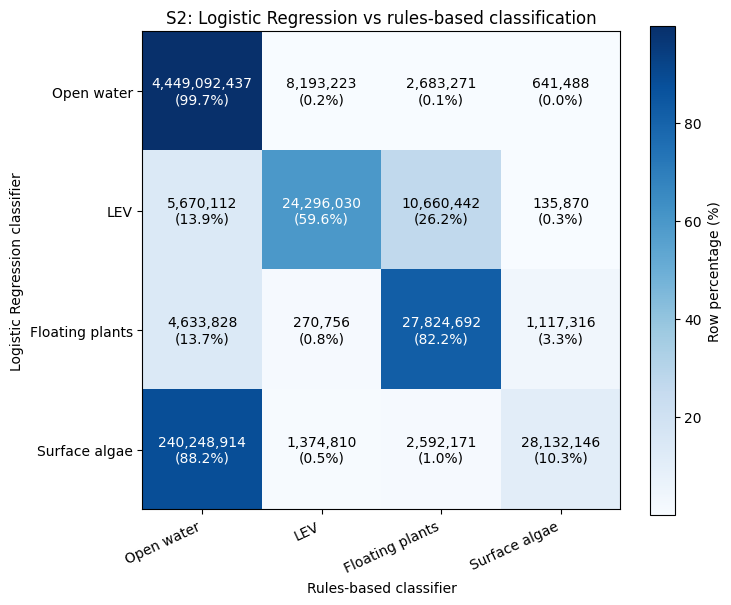

In [25]:
def plot_pooled_matrix(sensor, matrix):
    class_codes = class_codes_for(sensor)
    class_labels = class_labels_for(sensor)

    row_totals = matrix.sum(axis=1, keepdims=True)

    row_pct = np.divide(
        matrix,
        row_totals,
        out=np.zeros_like(matrix, dtype=float),
        where=row_totals != 0,
    ) * 100.0

    fig, ax = plt.subplots(figsize=(7.6, 6.2))
    im = ax.imshow(row_pct, cmap="Blues")

    labels = [class_labels[c] for c in class_codes]

    ax.set_xticks(
        range(len(labels)),
        labels=labels,
        rotation=25,
        ha="right",
    )
    ax.set_yticks(
        range(len(labels)),
        labels=labels,
    )

    ax.set_xlabel("Rules-based classifier")
    ax.set_ylabel("Logistic Regression classifier")
    ax.set_title(
        f"{sensor}: Logistic Regression vs rules-based classification"
    )

    for i in range(len(class_codes)):
        for j in range(len(class_codes)):
            # Optional: adjust text color based on background intensity for readability
            text_color = "white" if row_pct[i, j] > 50 else "black"
            ax.text(
                j,
                i,
                f"{int(matrix[i, j]):,}\n({row_pct[i, j]:.1f}%)",
                ha="center",
                va="center",
                color=text_color
            )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Row percentage (%)")

    fig.tight_layout()

    out = FIGURE_DIR / (
        f"{sensor.lower()}_rules_vs_lr_pooled_agreement_matrix.png"
    )
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    return out


for sensor, matrix in pooled_matrices.items():
    plot_pooled_matrix(sensor, matrix)


### B. Floating-plant mapped area through time

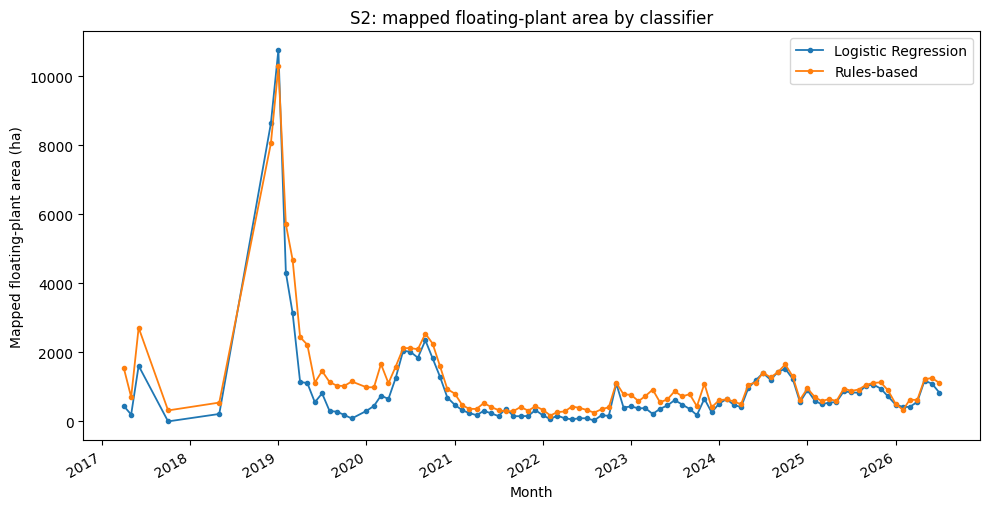

In [18]:
def plot_floating_area_time_series(sensor):
    d = monthly_df[
        monthly_df["sensor"] == sensor
    ].sort_values("month")

    if d.empty:
        return None

    fig, ax = plt.subplots(figsize=(10.0, 5.2))

    ax.plot(
        d["month"],
        d["floating_lr_area_ha"],
        marker="o",
        markersize=3,
        linewidth=1.3,
        label="Logistic Regression",
    )

    ax.plot(
        d["month"],
        d["floating_rule_area_ha"],
        marker="o",
        markersize=3,
        linewidth=1.3,
        label="Rules-based",
    )

    ax.set_xlabel("Month")
    ax.set_ylabel("Mapped floating-plant area (ha)")
    ax.set_title(
        f"{sensor}: mapped floating-plant area by classifier"
    )
    ax.legend()

    fig.autofmt_xdate()
    fig.tight_layout()

    out = FIGURE_DIR / (
        f"{sensor.lower()}_rules_vs_lr_floating_area_timeseries.png"
    )
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    return out


for sensor in SENSOR_FILTER:
    plot_floating_area_time_series(sensor)

### C. Difference in mapped floating-plant area

Positive values indicate that Logistic Regression mapped **more** floating-plant area than the rules-based classifier.

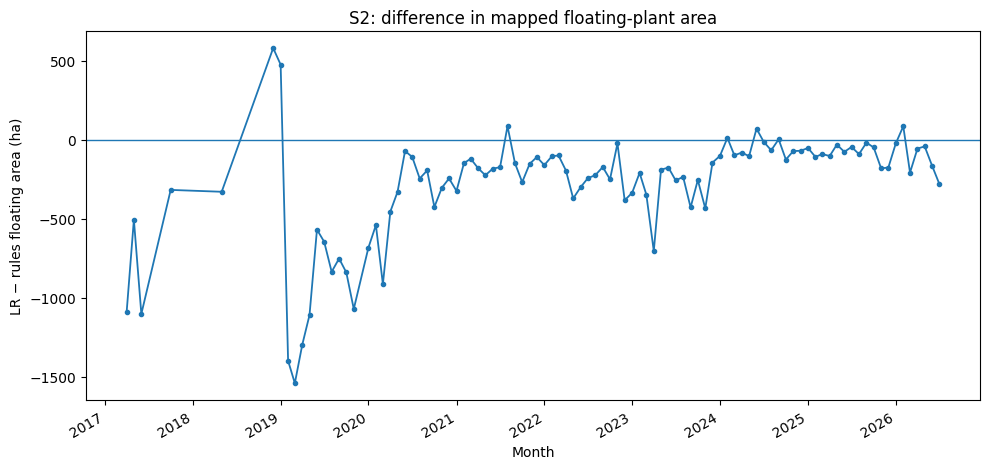

In [19]:
def plot_floating_area_difference(sensor):
    d = monthly_df[
        monthly_df["sensor"] == sensor
    ].sort_values("month")

    if d.empty:
        return None

    fig, ax = plt.subplots(figsize=(10.0, 4.8))

    ax.axhline(0, linewidth=1)
    ax.plot(
        d["month"],
        d["floating_area_difference_lr_minus_rules_ha"],
        marker="o",
        markersize=3,
        linewidth=1.3,
    )

    ax.set_xlabel("Month")
    ax.set_ylabel("LR − rules floating area (ha)")
    ax.set_title(
        f"{sensor}: difference in mapped floating-plant area"
    )

    fig.autofmt_xdate()
    fig.tight_layout()

    out = FIGURE_DIR / (
        f"{sensor.lower()}_rules_vs_lr_floating_area_difference.png"
    )
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    return out


for sensor in SENSOR_FILTER:
    plot_floating_area_difference(sensor)

### D. Scene-level agreement through time

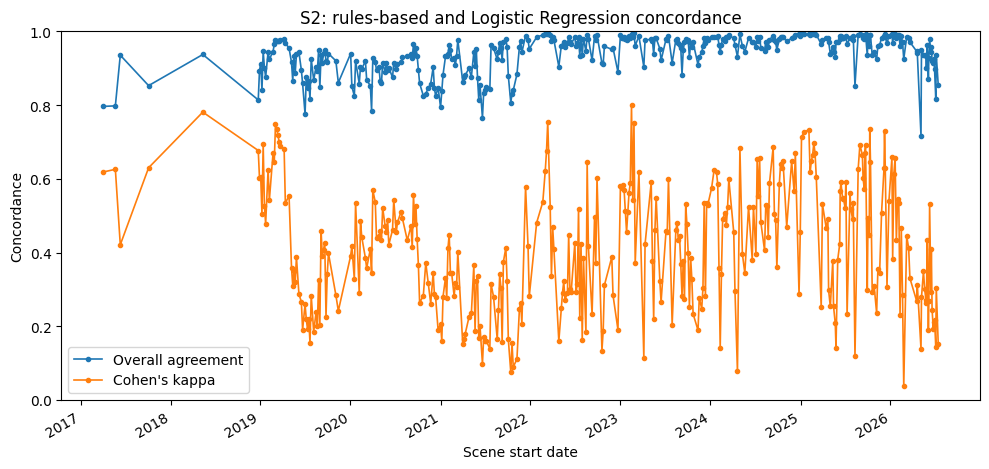

In [20]:
def plot_scene_agreement(sensor):
    d = scene_df[
        scene_df["sensor"] == sensor
    ].sort_values("start_date")

    if d.empty:
        return None

    fig, ax = plt.subplots(figsize=(10.0, 4.8))

    ax.plot(
        d["start_date"],
        d["overall_agreement"],
        marker="o",
        markersize=3,
        linewidth=1.2,
        label="Overall agreement",
    )

    ax.plot(
        d["start_date"],
        d["cohen_kappa"],
        marker="o",
        markersize=3,
        linewidth=1.2,
        label="Cohen's kappa",
    )

    ax.set_xlabel("Scene start date")
    ax.set_ylabel("Concordance")
    ax.set_ylim(0, 1)
    ax.set_title(
        f"{sensor}: rules-based and Logistic Regression concordance"
    )
    ax.legend()

    fig.autofmt_xdate()
    fig.tight_layout()

    out = FIGURE_DIR / (
        f"{sensor.lower()}_rules_vs_lr_agreement_timeseries.png"
    )
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    return out


for sensor in SENSOR_FILTER:
    plot_scene_agreement(sensor)

### E. Spatial disagreement quicklooks

For each sensor, the notebook renders the scenes with the highest disagreement fraction. The GeoTIFF itself remains the authoritative spatial output for QGIS.

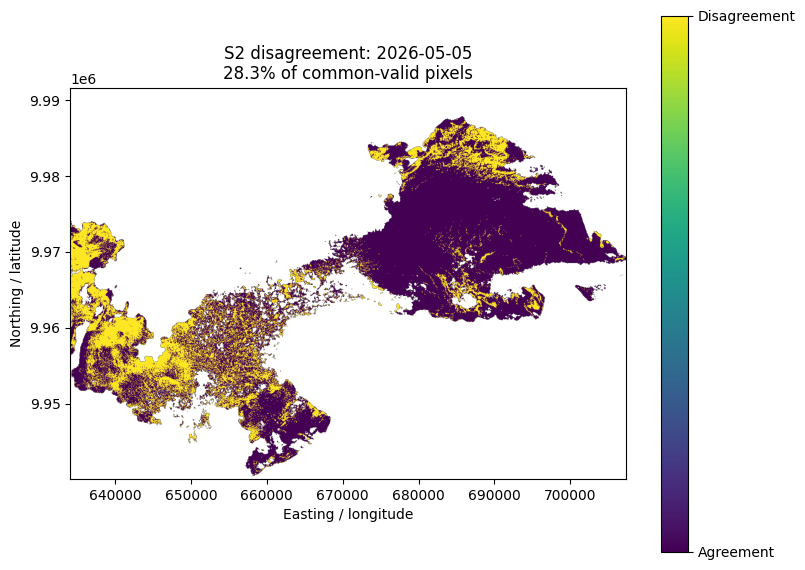

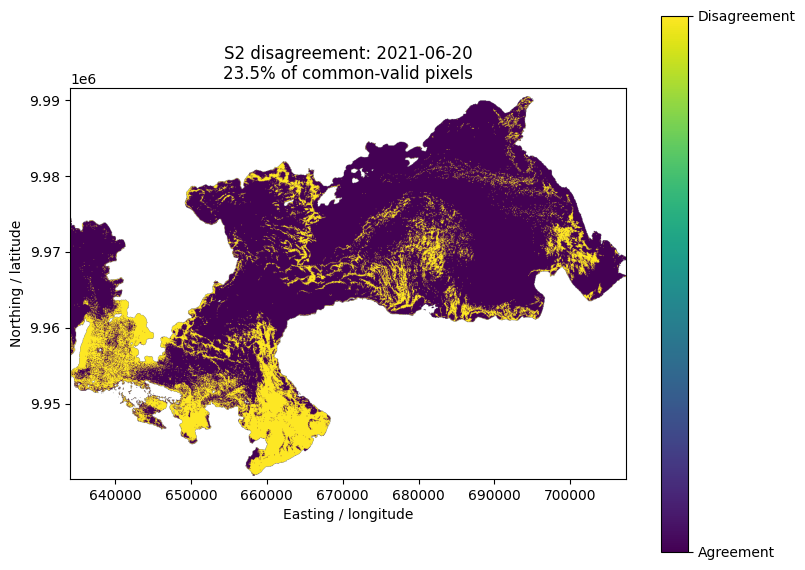

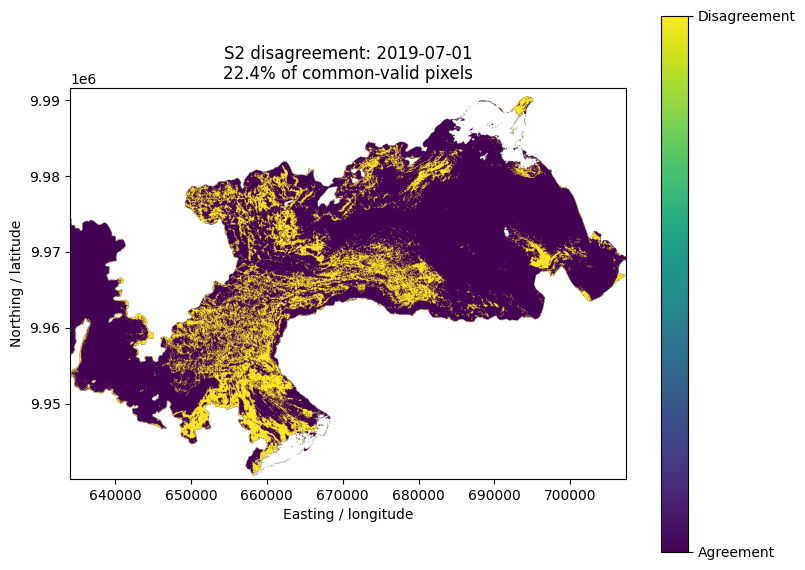

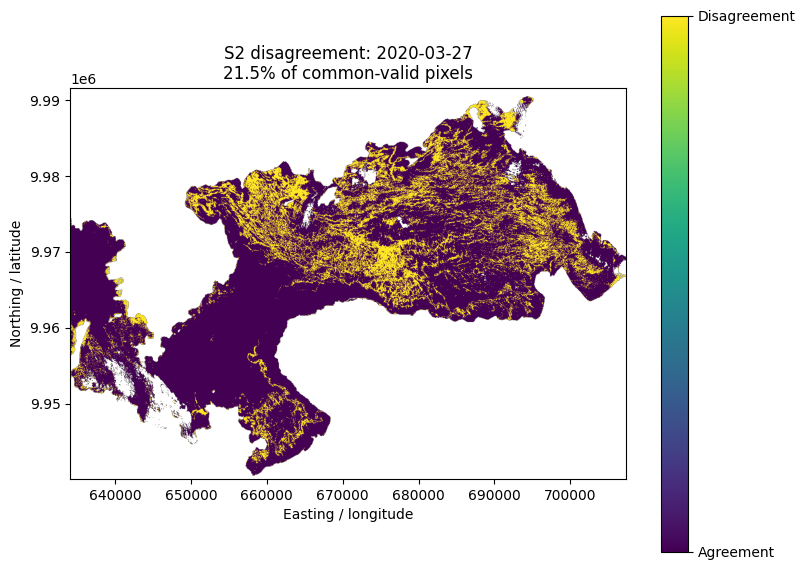

In [21]:
def plot_disagreement_quicklook(scene_row):
    tif = Path(scene_row["disagreement_tif"])
    if not tif.exists():
        return None

    local = staged_copy(tif)

    with rasterio.open(local) as src:
        scale = max(
            src.width / 1200,
            src.height / 1200,
            1,
        )

        out_w = max(1, int(src.width / scale))
        out_h = max(1, int(src.height / scale))

        arr = src.read(
            1,
            out_shape=(out_h, out_w),
            resampling=Resampling.nearest,
        )

        extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top,
        ]

    binary = np.full(arr.shape, np.nan, dtype=float)
    binary[arr == 0] = 0.0
    binary[
        (arr != 0) & (arr != NODATA_VALUE)
    ] = 1.0

    fig, ax = plt.subplots(figsize=(8.2, 5.8))

    im = ax.imshow(
        binary,
        extent=extent,
        origin="upper",
    )

    ax.set_xlabel("Easting / longitude")
    ax.set_ylabel("Northing / latitude")
    ax.set_title(
        f"{scene_row['sensor']} disagreement: "
        f"{scene_row['start_date'].date()}\n"
        f"{100 * scene_row['disagreement_fraction']:.1f}% "
        "of common-valid pixels"
    )

    cbar = fig.colorbar(
        im,
        ax=ax,
        ticks=[0, 1],
    )
    cbar.ax.set_yticklabels(
        ["Agreement", "Disagreement"]
    )

    fig.tight_layout()

    out = FIGURE_DIR / (
        f"{scene_row['sensor'].lower()}_"
        f"{scene_row['start_date'].date()}_"
        "rules_vs_lr_disagreement.png"
    )
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    return out


for sensor in SENSOR_FILTER:
    top = (
        scene_df[
            scene_df["sensor"] == sensor
        ]
        .sort_values(
            "disagreement_fraction",
            ascending=False,
        )
        .head(N_TOP_DISAGREEMENT_QUICKLOOKS)
    )

    for _, row in top.iterrows():
        plot_disagreement_quicklook(row)

## 11. Transition legend for disagreement GeoTIFFs

This table can be used to interpret raster values in QGIS. The legend is emitted **per sensor**, because the same transition value carries different class meanings under the S2 and S1 class codings.

In [22]:
legend_rows = []

for sensor in SENSOR_FILTER:
    class_codes = class_codes_for(sensor)
    class_labels = class_labels_for(sensor)

    legend_rows.append({
        "sensor": sensor,
        "value": 0,
        "meaning": "Agreement",
        "lr_code": np.nan,
        "lr_class": "",
        "rule_code": np.nan,
        "rule_class": "",
    })

    for lr_code in class_codes:
        for rule_code in class_codes:
            if lr_code == rule_code:
                continue

            value = (
                10 * (lr_code + 1)
                + (rule_code + 1)
            )

            legend_rows.append({
                "sensor": sensor,
                "value": value,
                "meaning": (
                    f"LR: {class_labels[lr_code]} -> "
                    f"Rules: {class_labels[rule_code]}"
                ),
                "lr_code": lr_code,
                "lr_class": class_labels[lr_code],
                "rule_code": rule_code,
                "rule_class": class_labels[rule_code],
            })

legend_df = pd.DataFrame(legend_rows).sort_values(
    ["sensor", "value"]
).reset_index(drop=True)

legend_df.to_csv(
    TABLE_DIR / "rules_vs_lr_disagreement_transition_legend.csv",
    index=False,
)

display(legend_df)

,sensor,value,meaning,lr_code,lr_class,rule_code,rule_class
0,S1,0,Agreement,NaN,,NaN,
1,S1,12,LR: Open water / surface algae -> Rules: LEV,0.0,Open water / surface algae,1.0,LEV
2,S1,13,LR: Open water / surface algae -> Rules: Floating plants,0.0,Open water / surface algae,2.0,Floating plants
3,S1,21,LR: LEV -> Rules: Open water / surface algae,1.0,LEV,0.0,Open water / surface algae
4,S1,23,LR: LEV -> Rules: Floating plants,1.0,LEV,2.0,Floating plants
5,S1,31,LR: Floating plants -> Rules: Open water / surface algae,2.0,Floating plants,0.0,Open water / surface algae
6,S1,32,LR: Floating plants -> Rules: LEV,2.0,Floating plants,1.0,LEV
7,S2,0,Agreement,NaN,,NaN,
8,S2,12,LR: Open water -> Rules: LEV,0.0,Open water,1.0,LEV
9,S2,13,LR: Open water -> Rules: Floating plants,0.0,Open water,2.0,Floating plants


## 12. Compact dissertation reporting table

This is deliberately descriptive and does not treat the rules-based classifier as a validation reference.

In [23]:
report_rows = []

for sensor in SENSOR_FILTER:
    ss = scene_df[
        scene_df["sensor"] == sensor
    ]

    if ss.empty:
        continue

    pooled = pooled_matrices[sensor]
    pooled_total = pooled.sum()

    report_rows.append({
        "Sensor": sensor,
        "Paired scenes": len(ss),
        "Pooled pixel agreement": (
            np.trace(pooled) / pooled_total
            if pooled_total else np.nan
        ),
        "Pooled Cohen kappa": (
            cohen_kappa_from_matrix(pooled)
        ),
        "Median scene agreement": (
            ss["overall_agreement"].median()
        ),
        "Median scene kappa": (
            ss["cohen_kappa"].median()
        ),
        "Mean floating IoU": (
            ss["floating_iou"].mean()
        ),
        "Mean floating Dice": (
            ss["floating_dice"].mean()
        ),
        "Mean LR floating area (ha)": (
            ss["floating_lr_area_ha"].mean()
        ),
        "Mean rules floating area (ha)": (
            ss["floating_rule_area_ha"].mean()
        ),
        "Mean LR-rules floating difference (ha)": (
            ss["floating_area_difference_lr_minus_rules_ha"].mean()
        ),
        "Mean absolute floating difference (ha)": (
            ss["floating_absolute_area_difference_ha"].mean()
        ),
    })

report_df = pd.DataFrame(report_rows)

report_df.to_csv(
    TABLE_DIR / "rules_vs_lr_dissertation_summary.csv",
    index=False,
)

display(report_df.round(4))

,Sensor,Paired scenes,Pooled pixel agreement,Pooled Cohen kappa,Median scene agreement,Median scene kappa,Mean floating IoU,Mean floating Dice,Mean LR floating area (ha),Mean rules floating area (ha),Mean LR-rules floating difference (ha),Mean absolute floating difference (ha)
0,S2,372,0.9421,0.3745,0.9575,0.4107,0.4979,0.6251,909.8546,1176.3596,-266.5049,329.9154


## 13. Interpretation guardrails

Use the outputs to answer questions such as:

- How closely did the local rules and Logistic Regression classifications agree?
- Which classes were most frequently exchanged between methods?
- Did Logistic Regression systematically map more or less floating vegetation?
- Did the size of the difference vary through time or between S2 and S1?
- Where were method disagreements spatially concentrated?

Do **not** describe higher agreement as higher accuracy unless the comparison is independently tied to labelled validation data. The rules-based classifier is a comparator, not a reference truth.

## 14. Output inventory

In [24]:
print("Tables")
for p in sorted(TABLE_DIR.glob("*.csv")):
    print(" -", p)

print("\nFigures")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(" -", p)

if WRITE_DISAGREEMENT_RASTERS:
    rasters = sorted(
        DISAGREEMENT_DIR.glob("*.tif")
    )

    print("\nDisagreement GeoTIFFs")
    for p in rasters[:20]:
        print(" -", p)

    if len(rasters) > 20:
        print(
            f" ... and {len(rasters) - 20} more"
        )

print("\nDone.")

Tables
 - /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/tables/rules_vs_lr_agreement_matrix_by_scene.csv
 - /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/tables/rules_vs_lr_class_comparison_by_scene.csv
 - /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/tables/rules_vs_lr_disagreement_transition_legend.csv
 - /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/tables/rules_vs_lr_discovery_audit.csv
 - /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/tables/rules_vs_lr_dissertation_summary.csv
 - /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/tables/rules_vs_lr_monthly_comparison.csv
 - /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_regression/tables/rules_vs_lr_paired_manifest.csv
 - /content/drive/MyDrive/Winam_RF_Training_Data/outputs/rules_vs_logistic_